In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# <span style="color:red"> ch5. LSTM/GRU </span>

- 5만개 영화 감상평(독립변수) -> 긍정/부정(타겟변수)


# 1. 패키지

In [2]:

import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from time import time # 70.01.01부터 현재까지의 밀리세컨

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# 2. 하이퍼 파라미터 설정 
- 이 파라미터를 바꾸면 정확도나 학습 속도에 영향을 미침. 주로 반비례 관계로 영향을 줌

In [93]:
MY_WORDS = 10000  # imdb 데이터에서 가져올 단어 개수
MY_LENGTH = 170    # 영화평 단어수 80개만 독립변수
MY_EMBED = 128     # 임베딩 레이어의 결과 차원
MY_HIDDEN = 64    # 히든레이어의 유닛수
# FIT
MY_EPOCH = 30     # 학습 수
MY_BATCH = 200    # 배치사이즈

# 3. 데이터 불러오기

In [94]:

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MY_WORDS)

In [16]:
print('학습용 입력 변수 모양 :', x_train.shape)
print('학습용 타겟 변수 모양 :', y_train.shape)
print('학습셋 샘플 :', type(x_train[1]), x_train[1], y_train[1])
print('테스트용 입력 변수 모양 :', x_test.shape)
print('테스트용 타겟 변수 모양 :', y_test.shape)

학습용 입력 변수 모양 : (25000,)
학습용 타겟 변수 모양 : (25000,)
학습셋 샘플 : <class 'list'> [1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 8163, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 6853, 5, 163, 11, 3215, 2, 4, 1153, 9, 194, 775, 7, 8255, 2, 349, 2637, 148, 605, 2, 8003, 15, 123, 125, 68, 2, 6853, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 2, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 8255, 5, 2, 656, 245, 2350, 5, 4, 9837, 131, 152, 491, 18, 2, 32, 7464, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95] 0
테스트용 입력 변수 모양 : (25000,)
테스트용 타겟 변수 모양 : (25000,)


In [20]:
# 긍정 / 부정 비율
print(type(y_train))
print('학습셋의 긍정 갯수 : ', y_train.sum())
print('테스트용 셋의 긍정 갯수 : ', y_test.sum())

<class 'numpy.ndarray'>
학습셋의 긍정 갯수 :  12500
테스트용 셋의 긍정 갯수 :  12500


# 4. 문자단어 -> 정수

In [34]:
# 데이터들은 모두 숫자로 되어있으니, 우리는 무슨 말인지 궁금하다. 변환해보자
word_to_id = imdb.get_word_index()  # 각 단어와 숫자의 매칭 정보가 담긴 딕셔너리
id_to_word = {}
for word, idx in word_to_id.items():
    id_to_word[idx] = word
id_to_word

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [44]:
word_to_id['wonderful']

386

In [52]:
msg = "What a wonderful movie"
msg = msg.lower().split()
msg
# 1 : 리뷰 시작을 알리는 숫자, 2: 문자가 잘려서 잘못 읽어옴, 3: 패딩 처리
# 위의 3개 값이 배정되어 있으므로 코드에 +3
data = [1] + [ word_to_id[m] +3 for m in msg ]
print('원 후기 내용 :', msg)
print('encoded data :', data)
print()

msg1 = "What a wonderful movi"  # 없는 단어는 -1로 반환시키자
msg1 = msg1.lower().split()
data = [1] + [ word_to_id.get(m, -1) +3 for m in msg1 ]
print('원 후기 내용 :', msg1)
print('encoded data :', data)
print()

msg2 = "What a wonderful ??"  # 문자가 잘리면 ??표로 인식됨
msg2 = msg2.lower().split()
data = [1] + [ word_to_id.get(m, -1) +3 for m in msg2 ]
print('원 후기 내용 :', msg2)
print('encoded data :', data)

원 후기 내용 : ['what', 'a', 'wonderful', 'movie']
encoded data : [1, 51, 6, 389, 20]

원 후기 내용 : ['what', 'a', 'wonderful', 'movi']
encoded data : [1, 51, 6, 389, 2]

원 후기 내용 : ['what', 'a', 'wonderful', '??']
encoded data : [1, 51, 6, 389, 2]


In [58]:
msg = "What a wonderful movie"
msg = msg.lower().split()
msg
# 1 : 리뷰 시작을 알리는 숫자, 2: 문자가 잘려서 잘못 읽어옴, 3: 패딩 처리
# 위의 3개 값이 배정되어 있으므로 코드에 +3
data = [1] + [ word_to_id[m] +3 for m in msg ]
print('원 후기 내용 :', msg)
print('encoded data :', data)
print('encoded data :', [id_to_word.get(d-3, '???') for d in data])



원 후기 내용 : ['what', 'a', 'wonderful', 'movie']
encoded data : [1, 51, 6, 389, 20]



['???', 'what', 'a', 'wonderful', 'movie']

# 5. 숫자영화평 -> 자연어 영화평

In [59]:
def decoding(review_num):
    decoded = [id_to_word.get(d-3, '???') for d in review_num]
    return ' '.join(decoded)

In [60]:
print(y_train, decoding(x_train[1]))

"??? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal ??? the hair is big lots of boobs ??? men wear those cut ??? shirts that show off their ??? sickening that men actually wore them and the music is just ??? trash that plays over and over again in almost every scene there is trashy music boobs and ??? taking away bodies and the gym still doesn't close for ??? all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then"

In [73]:
def show_length(x_train):
    print('영화평 단어개수')
    print([len(x_data) for x_data in x_train[:20]])
show_length(x_train)

영화평 단어개수
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177]


In [68]:
print('제일 긴 영화평 길이 :', max([len(x_data) for x_data in x_train]))

print('제일 짧은 영화평 길이 :', min([len(x_data) for x_data in x_train]))

print('단어 길이 중위수', np.median([len(x_data) for x_data in x_train]) )

제일 긴 영화평 길이 : 2494
제일 짧은 영화평 길이 : 11
단어 길이 중위수 178.0


# 7. 모든 영화평 길이를 동일하게 (80)

In [95]:
X_train = pad_sequences(x_train,
                       padding='post',  # 앞에서 부터 채움
                       truncating='post',  # 뒷부분을 자르고 앞부분을 남김
                       maxlen=MY_LENGTH)
X_test =  pad_sequences(x_test,
                       padding='post',  # 앞에서 부터 채움
                       truncating='post',  # 뒷부분을 자르고 앞부분을 남김
                       maxlen=MY_LENGTH)
show_length(X_train), show_length(X_test)

영화평 단어개수
[170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170]
영화평 단어개수
[170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170]


(None, None)

# 8. 최종 데이터 shape 확인

In [79]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

In [84]:
MY_WORDS, MY_EMBED, MY_HIDDEN, MY_LENGTH

(10000, 32, 64, 80)

# 9. 모델 생성

In [96]:
model = Sequential()
model.add(Embedding(input_dim=MY_WORDS,
                   output_dim=MY_EMBED,
                   input_length=MY_LENGTH))
# RNN : 입력 단어의 길이 수가 너무 길면 파리미터 업데이트 안 됨
# 개선모델1. LSTM 개선모델2. GRU
model.add(LSTM(MY_HIDDEN,
              input_shape=(MY_LENGTH, MY_EMBED)
              ))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 170, 128)          1280000   
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1,329,473
Trainable params: 1,329,473
Non-trainable params: 0
_________________________________________________________________


# 10. 학습환경 설정 및 실행

In [97]:

model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['acc'])
begin = time()
print(begin)
hist = model.fit(X_train, y_train,
                epochs=MY_EPOCH,
                batch_size=MY_BATCH,
                validation_split=0.3,
                verbose=1,
                )
end = time()
print('총 학습시간 :', end-begin, '초')

1750405791.8243365
Epoch 1/30
88/88 [==============================] - 31s 331ms/step - loss: 0.6100 - acc: 0.6350 - val_loss: 0.4206 - val_acc: 0.8324
Epoch 2/30
88/88 [==============================] - 28s 317ms/step - loss: 0.3354 - acc: 0.8709 - val_loss: 0.3700 - val_acc: 0.8619
Epoch 3/30
88/88 [==============================] - 29s 327ms/step - loss: 0.2316 - acc: 0.9169 - val_loss: 0.3986 - val_acc: 0.8576
Epoch 4/30
88/88 [==============================] - 29s 327ms/step - loss: 0.1751 - acc: 0.9425 - val_loss: 0.3614 - val_acc: 0.8557
Epoch 5/30
88/88 [==============================] - 30s 342ms/step - loss: 0.1362 - acc: 0.9579 - val_loss: 0.3946 - val_acc: 0.8469
Epoch 6/30
88/88 [==============================] - 32s 363ms/step - loss: 0.1041 - acc: 0.9698 - val_loss: 0.5363 - val_acc: 0.8445
Epoch 7/30
88/88 [==============================] - 30s 340ms/step - loss: 0.0915 - acc: 0.9739 - val_loss: 0.4881 - val_acc: 0.8452
Epoch 8/30
88/88 [==============================] 

# 11. 평가하기

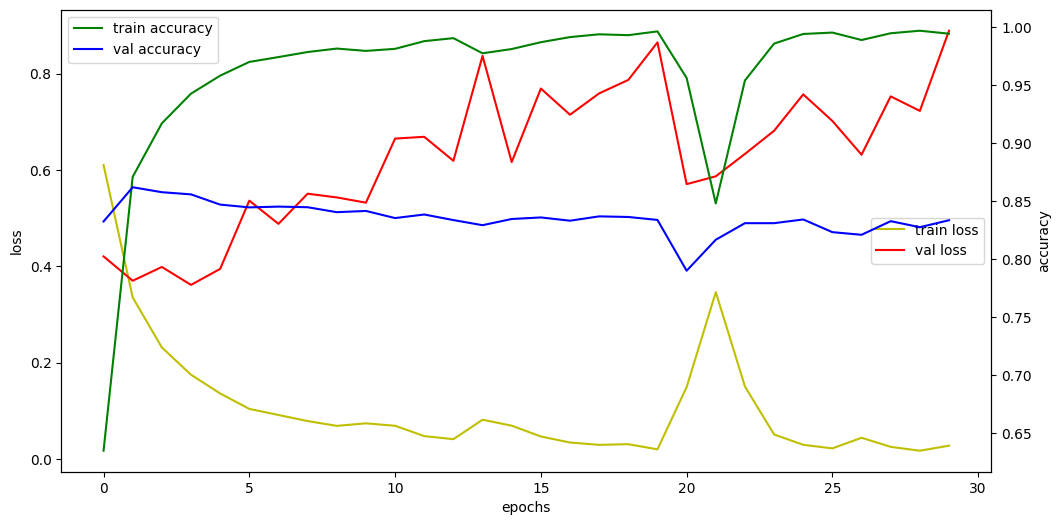

In [98]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_acc'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [99]:
loss, acc = model.evaluate(X_test, y_test)
print('정확도 :', acc)

782/782 [==============================] - 20s 25ms/step - loss: 0.9999 - acc: 0.8129
정확도 : 0.8129199743270874


In [100]:
# 혼동행렬, recall, precision을 위한 yhat
yhat = (model.predict(X_test,
                     verbose=1) > 0.5)

782/782 [==============================] - 20s 25ms/step
